In [1]:
import pandas as pd
from pathlib import Path

prepared_root = Path("data/prepared/pannuke")
csv_path = prepared_root / "instance_class_map.csv"

df = pd.read_csv(csv_path)

rows = []

for split in ["train", "val", "test"]:
    img_dir = prepared_root / split / "images"
    n_images = len(list(img_dir.glob("img_*.npy")))

    df_split = df[df["split"] == split]

    n_instances = len(df_split)

    class_counts = (
        df_split["class_id"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    row = {
        "split": split,
        "n_images": n_images,
        "n_instances": n_instances,
        "instances_per_image": round(n_instances / n_images, 2) if n_images > 0 else 0,
    }

    # ajouter chaque classe comme colonne
    for class_id, count in class_counts.items():
        row[f"class_{class_id}"] = count

    rows.append(row)

summary_df = pd.DataFrame(rows).fillna(0).astype({"n_images": int, "n_instances": int})

print(summary_df)
summary_df.to_csv(prepared_root / "dataset_statistics_by_split.csv", index=False)


   split  n_images  n_instances  instances_per_image  class_1  class_2  \
0  train      2620        54447                20.78    21765     9553   
1    val      2465        51719                20.98    18808     9441   
2   test      2656        56829                21.40    23045     9561   

   class_3  class_4  class_5  
0    15063      905     7161  
1    15362      838     7270  
2    16027      960     7236  


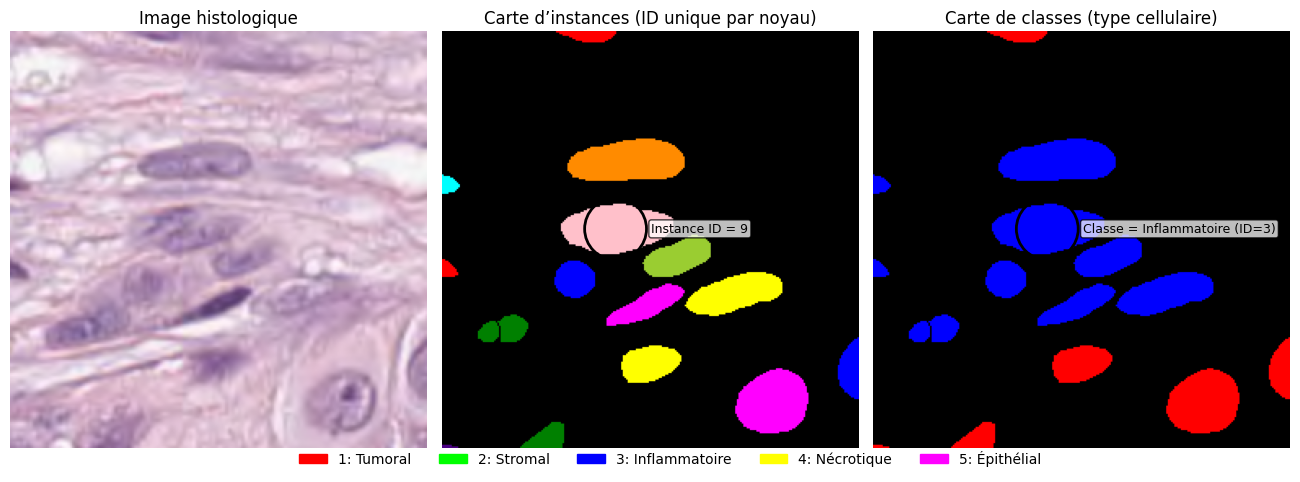

[OK] Figure sauvegardée: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\pannuke_preparation_example_annotated.png
[INFO] Exemple annoté: instance_id=9 | class_id=3 (Inflammatoire) | image=img_000029.npy


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.color import label2rgb
from skimage.measure import regionprops
from matplotlib.patches import Circle
import matplotlib.patches as mpatches

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
prepared_root = Path("data/prepared/pannuke")
split = "train"
out_path = Path("pannuke_preparation_example_annotated.png")

# couleurs fixes pour les classes (à garder cohérentes dans tout le mémoire)
class_colors = {
    1: (1, 0, 0),     # Tumoral (ex)
    2: (0, 1, 0),     # Stromal
    3: (0, 0, 1),     # Inflammatoire
    4: (1, 1, 0),     # Nécrotique
    5: (1, 0, 1),     # Épithélial
}
class_names = {
    1: "Tumoral",
    2: "Stromal",
    3: "Inflammatoire",
    4: "Nécrotique",
    5: "Épithélial",
}

# ------------------------------------------------------------
# Pick a sample
# ------------------------------------------------------------
img_files = sorted((prepared_root / split / "images").glob("img_*.npy"))
if not img_files:
    raise FileNotFoundError(f"Aucune image trouvée dans {prepared_root / split / 'images'}")

img_path = img_files[28]
mask_path = prepared_root / split / "masks" / img_path.name.replace("img_", "mask_")
type_path = prepared_root / split / "types" / img_path.name.replace("img_", "type_")

img = np.load(img_path)         # (H,W,3)
inst = np.load(mask_path)       # (H,W) instance ids
type_map = np.load(type_path)   # (H,W) class ids (pixel-wise)

# ------------------------------------------------------------
# Build class RGB map
# ------------------------------------------------------------
type_rgb = np.zeros((*type_map.shape, 3), dtype=np.float32)
for cid, col in class_colors.items():
    type_rgb[type_map == cid] = col

# ------------------------------------------------------------
# Choose a "good" instance to annotate (not too small)
# ------------------------------------------------------------
props = regionprops(inst)
if not props:
    raise RuntimeError("Aucune instance détectée dans ce masque (inst est vide).")

# filtre les micro-objets pour que l’annotation soit visible
props = sorted(props, key=lambda p: p.area, reverse=True)
chosen = None
for p in props:
    if p.area >= 80:  # ajuste si besoin
        chosen = p
        break
if chosen is None:
    chosen = props[0]  # au pire, prends la plus grande

inst_id = int(chosen.label)
cy, cx = chosen.centroid  # (row, col)

# déduire class_id majoritaire de cette instance (à partir de type_map)
pix = (inst == inst_id)
cls_vals = type_map[pix]
cls_vals = cls_vals[cls_vals > 0]
if cls_vals.size == 0:
    class_id = 0
    class_label = "Inconnue"
else:
    binc = np.bincount(cls_vals.astype(np.int32))
    class_id = int(np.argmax(binc))
    class_label = class_names.get(class_id, f"Classe {class_id}")

# rayon du cercle: basé sur la taille de l’instance (lisible sans être énorme)
radius = max(8, int(np.sqrt(chosen.area) / 2))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(13.5, 4.6))

# 1) image
ax1 = plt.subplot(1, 3, 1)
ax1.set_title("Image histologique")
ax1.imshow(img)
ax1.axis("off")

# 2) instances
ax2 = plt.subplot(1, 3, 2)
ax2.set_title("Carte d’instances (ID unique par noyau)")
ax2.imshow(label2rgb(inst, bg_label=0))
ax2.axis("off")

# cercle + texte sur carte instances
ax2.add_patch(Circle((cx, cy), radius=radius, fill=False, linewidth=2))
ax2.text(
    cx + radius + 3, cy,
    f"Instance ID = {inst_id}",
    fontsize=9, va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75)
)

# 3) classes
ax3 = plt.subplot(1, 3, 3)
ax3.set_title("Carte de classes (type cellulaire)")
ax3.imshow(type_rgb)
ax3.axis("off")

# cercle + texte sur carte classes
ax3.add_patch(Circle((cx, cy), radius=radius, fill=False, linewidth=2))
ax3.text(
    cx + radius + 3, cy,
    f"Classe = {class_label} (ID={class_id})",
    fontsize=9, va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75)
)

# ------------------------------------------------------------
# Légende des classes (petite et lisible)
# ------------------------------------------------------------
legend_patches = []
for cid in sorted(class_colors.keys()):
    patch = mpatches.Patch(color=class_colors[cid], label=f"{cid}: {class_names[cid]}")
    legend_patches.append(patch)

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Figure sauvegardée: {out_path.resolve()}")
print(f"[INFO] Exemple annoté: instance_id={inst_id} | class_id={class_id} ({class_label}) | image={img_path.name}")


C:\Users\yehadji\AppData\Local\Temp\ipykernel_159908\933720287.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


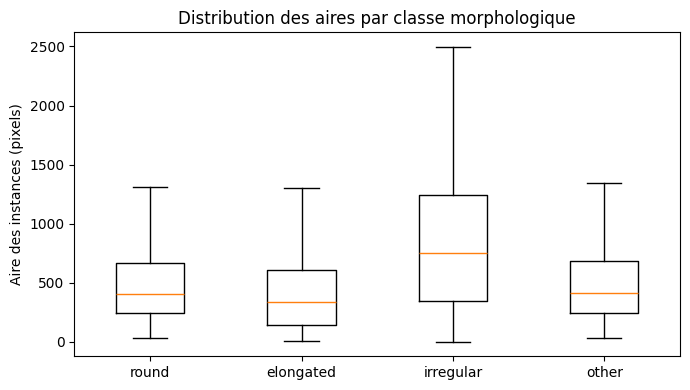

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv("data/prepared/pannuke/pannuke_morphology_with_classes.csv")

# option: limiter les très grands outliers pour lisibilité
df_plot = df[df["area"] <= df["area"].quantile(0.99)]

plt.figure(figsize=(7, 4))
plt.boxplot(
    [df_plot[df_plot["morph_class"] == mc]["area"].values
     for mc in ["round", "elongated", "irregular", "other"]],
    labels=["round", "elongated", "irregular", "other"],
    showfliers=False
)

plt.ylabel("Aire des instances (pixels)")
plt.title("Distribution des aires par classe morphologique")
plt.tight_layout()
plt.savefig("pannuke_area_boxplot_by_morph.png", dpi=300)
plt.show()


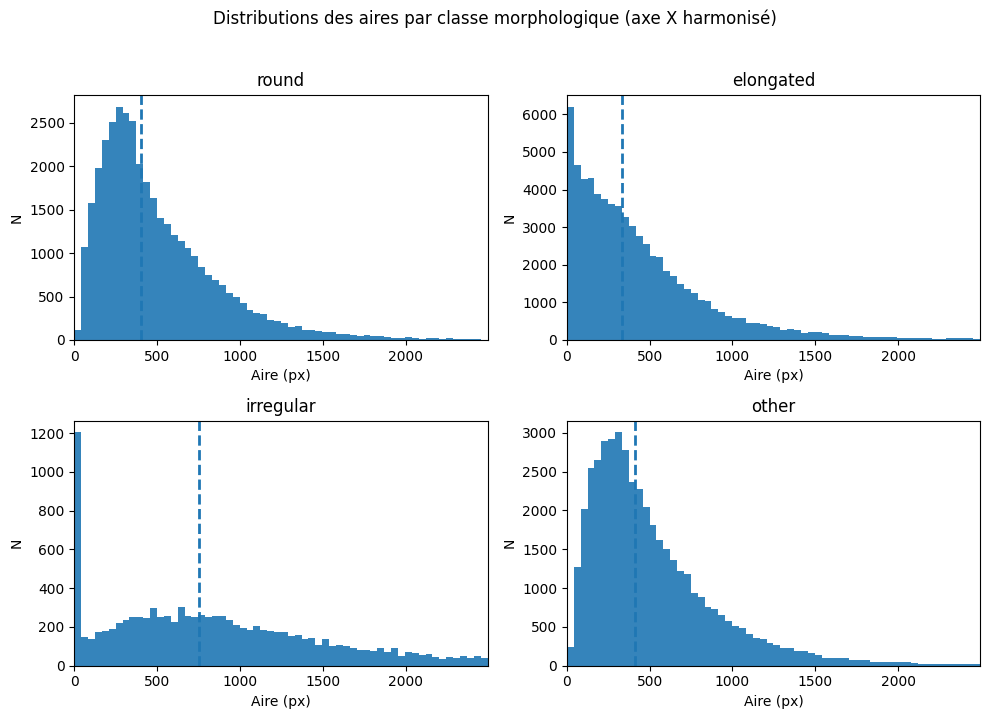

[OK] Saved: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\pannuke_area_hist_per_morph_fixed.png
[INFO] xlim: [0, 2495.1] (quantile=0.99) | bins=60


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# Paths / config
# -------------------------
prepared_root = Path("data/prepared/pannuke")
csv_path = prepared_root / "pannuke_morphology_with_classes.csv"

out_path = Path("pannuke_area_hist_per_morph_fixed.png")

morphs = ["round", "elongated", "irregular", "other"]

# Pour la lisibilité : même échelle X partout (tronque les extrêmes)
# 0.99 est un bon compromis pour éviter que 1% d'outliers écrase tout
x_q = 0.99

# Nombre de bins (on peux ajuster, 50-80 marche souvent)
n_bins = 60

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(csv_path)

# Option : choisir un split précis (sinon commente)
# df = df[df["split"] == "train"].copy()

# Nettoyage minimal
df = df[df["area"].notna()].copy()

# -------------------------
# Shared bins + shared xlim
# -------------------------
xmax = float(df["area"].quantile(x_q))
xmin = 0.0
bins = np.linspace(xmin, xmax, n_bins + 1)

# -------------------------
# Plot: 2x2 histograms
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for ax, mc in zip(axes, morphs):
    sub = df[df["morph_class"] == mc]["area"].values
    sub = sub[sub <= xmax]  # tronque les extrêmes pour être cohérent avec xlim

    if sub.size == 0:
        ax.set_title(mc)
        ax.text(0.5, 0.5, "Aucune donnée", ha="center", va="center", transform=ax.transAxes)
        ax.set_xlim(xmin, xmax)
        ax.set_xlabel("Aire (px)")
        ax.set_ylabel("N")
        continue

    ax.hist(sub, bins=bins, alpha=0.9)
    ax.set_title(mc)

    # médiane (très parlant en mémoire)
    med = float(np.median(sub))
    ax.axvline(med, linestyle="--", linewidth=2)

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Aire (px)")
    ax.set_ylabel("N")

# Titre global
fig.suptitle("Distributions des aires par classe morphologique (axe X harmonisé)", y=1.02)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Saved: {out_path.resolve()}")
print(f"[INFO] xlim: [0, {xmax:.1f}] (quantile={x_q}) | bins={n_bins}")


Nb images: 2465


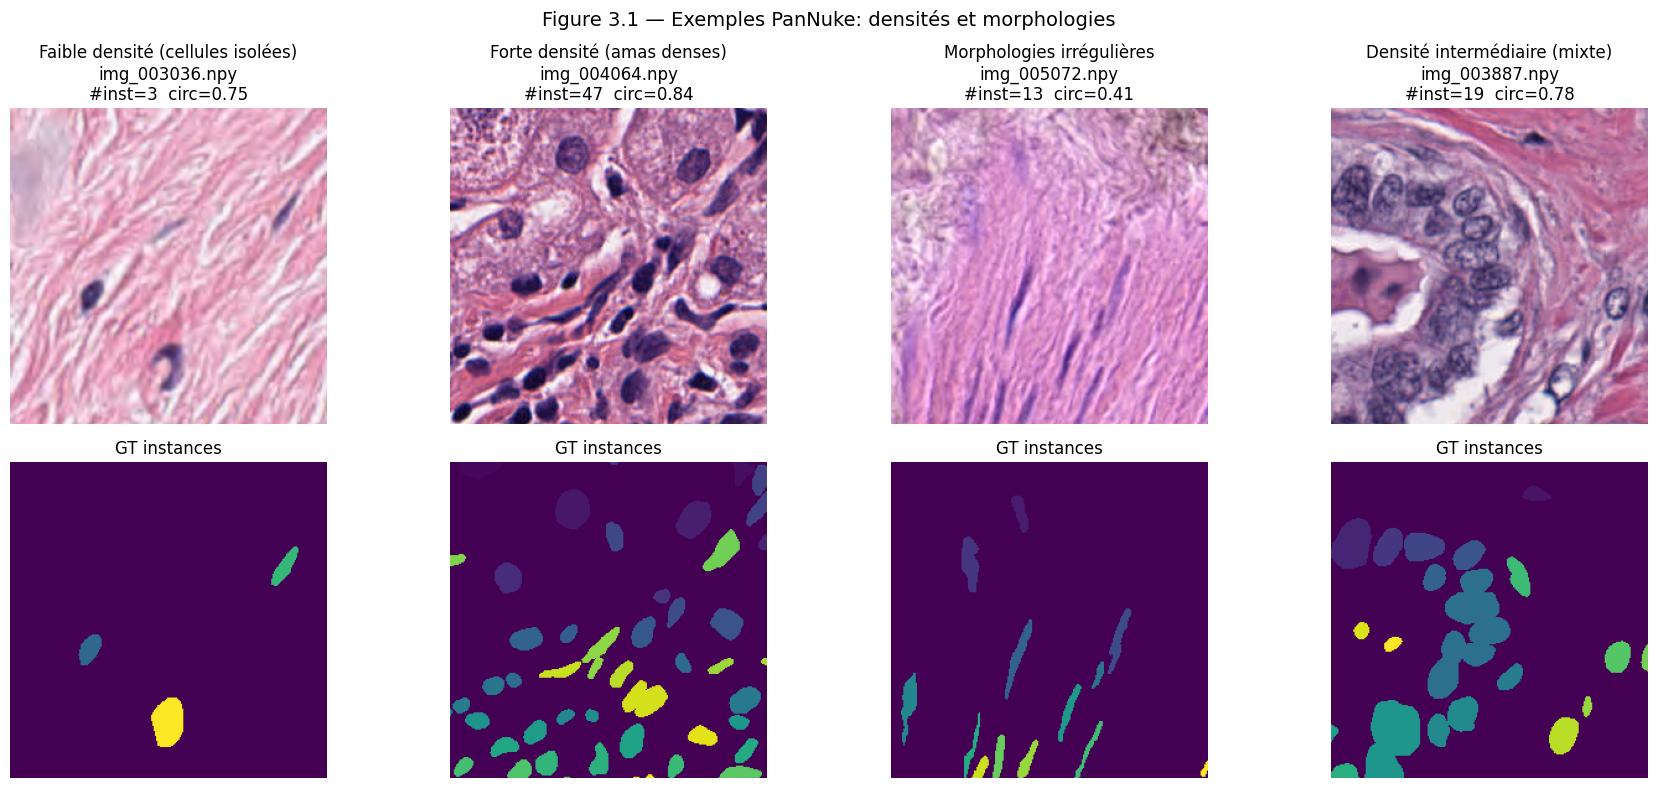

Saved: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\figure_3_1_pannuke_examples.png


In [21]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Mesures morpho simples
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries

from src.pannuke_dataset import PannukePreparedDataset

# -----------------------------
# 1) Charger le dataset
# -----------------------------
DATA_ROOT = Path("data/prepared/pannuke")  # <-- ajuste si besoin
SPLIT = "val"  # ou "train"

ds = PannukePreparedDataset(
    root=DATA_ROOT,
    split=SPLIT,
    transform=None,
    return_image_name=True
)

print("Nb images:", len(ds))

# -----------------------------
# 2) Fonctions d'analyse
# -----------------------------
def count_instances(mask: np.ndarray) -> int:
    # mask: (H,W) int
    return int(mask.max())

def mean_circularity(mask: np.ndarray, max_instances=80) -> float:
    """
    Circularité moyenne (4πA / P²) sur quelques instances
    1.0 ~ rond, plus petit ~ irrégulier/allongé.
    On sous-échantillonne pour éviter que ça prenne 3 siècles.
    """
    m = mask.astype(np.int32, copy=False)
    n = int(m.max())
    if n == 0:
        return 1.0

    # sous-échantillonnage des ids si trop d'instances
    ids = np.arange(1, n + 1)
    if len(ids) > max_instances:
        rng = np.random.default_rng(0)
        ids = rng.choice(ids, size=max_instances, replace=False)

    circs = []
    for k in ids:
        bin_k = (m == k)
        if bin_k.sum() < 10:
            continue
        props = regionprops(bin_k.astype(np.uint8))
        if not props:
            continue
        p = props[0].perimeter
        a = props[0].area
        if p <= 1e-6:
            continue
        circ = (4.0 * np.pi * a) / (p * p + 1e-6)
        circs.append(circ)

    if len(circs) == 0:
        return 1.0
    return float(np.mean(circs))

def get_item(i):
    img_t, mask_t, types_t, name = ds[i]  # img (3,H,W), mask (H,W)
    img = img_t.permute(1,2,0).cpu().numpy()
    mask = mask_t.cpu().numpy().astype(np.int32)
    return img, mask, name

# -----------------------------
# 3) Scorer et choisir des exemples
# -----------------------------
# On passe sur un sous-ensemble si ton val est énorme
N_SCAN = min(len(ds), 600)
idxs = np.linspace(0, len(ds)-1, N_SCAN).astype(int)

stats = []
for i in idxs:
    img, mask, name = get_item(i)
    n_inst = count_instances(mask)
    circ = mean_circularity(mask)
    stats.append((i, name, n_inst, circ))

# Tri densité
stats_sorted_by_n = sorted(stats, key=lambda x: x[2])
low_density = stats_sorted_by_n[len(stats_sorted_by_n)//20]  # ~5% percentile
high_density = stats_sorted_by_n[-len(stats_sorted_by_n)//20] # ~95% percentile

# Image "mixte" densité médiane
mid_density = stats_sorted_by_n[len(stats_sorted_by_n)//2]

# Tri irrégularité: circularité faible => formes irrégulières/allongées
stats_sorted_by_irreg = sorted(stats, key=lambda x: x[3])  # circ asc
irregular = stats_sorted_by_irreg[0]

chosen = [
    ("Faible densité (cellules isolées)", low_density),
    ("Forte densité (amas denses)", high_density),
    ("Morphologies irrégulières", irregular),
    ("Densité intermédiaire (mixte)", mid_density),
]

# -----------------------------
# 4) Plot Figure 3.1
# -----------------------------
def overlay_instances_on_image(img, mask):
    # contours d'instances
    b = find_boundaries(mask, mode="outer")
    out = img.copy()
    # contours en blanc
    out[b] = 1.0
    return out

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, (title, (i, name, n_inst, circ)) in enumerate(chosen):
    img, mask, _ = get_item(i)

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{title}\n{name}\n#inst={n_inst}  circ={circ:.2f}")
    axes[0, col].axis("off")

    # GT instances (affichage brut) + overlay contours
    axes[1, col].imshow(mask)
    axes[1, col].set_title("GT instances")
    axes[1, col].axis("off")

# plt.suptitle("Figure 3.1 — Exemples PanNuke: densités et morphologies", fontsize=14)
plt.tight_layout()
plt.show()

# Sauvegarde
out_path = Path("figure_3_1_pannuke_examples.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved:", out_path.resolve())


Nb images: 2465


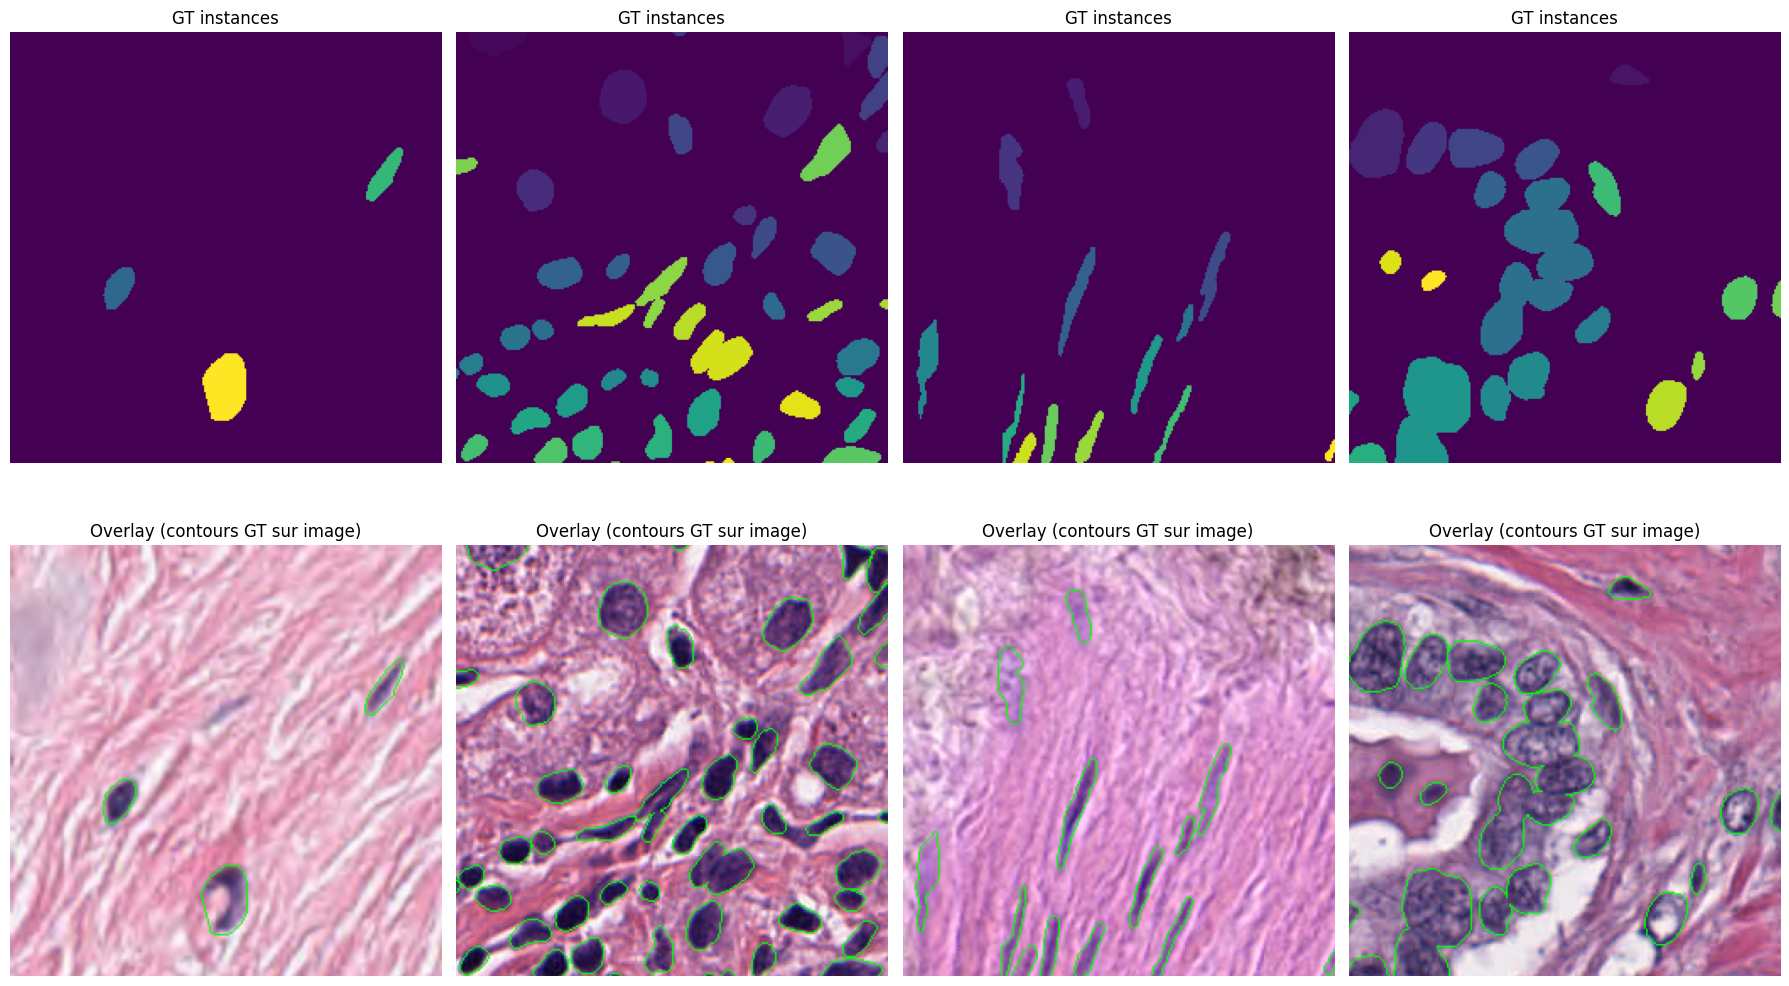

Saved: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\figure_3_1_pannuke_examples_overlay.png


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage.measure import regionprops
from skimage.segmentation import find_boundaries

from src.pannuke_dataset import PannukePreparedDataset


# -----------------------------
# 1) Charger le dataset
# -----------------------------
DATA_ROOT = Path("data/prepared/pannuke")  # <-- ajuste si besoin
SPLIT = "val"  # "train" / "val" / "test"

ds = PannukePreparedDataset(
    root=DATA_ROOT,
    split=SPLIT,
    transform=None,
    return_image_name=True
)

print("Nb images:", len(ds))


# -----------------------------
# 2) Fonctions d'analyse
# -----------------------------
def count_instances(mask: np.ndarray) -> int:
    return int(mask.max())

def mean_circularity(mask: np.ndarray, max_instances=80) -> float:
    """
    Circularité moyenne (4πA / P²) sur un sous-ensemble d'instances.
    1.0 ~ rond, plus petit ~ irrégulier/allongé.
    """
    m = mask.astype(np.int32, copy=False)
    n = int(m.max())
    if n == 0:
        return 1.0

    ids = np.arange(1, n + 1)
    if len(ids) > max_instances:
        rng = np.random.default_rng(0)
        ids = rng.choice(ids, size=max_instances, replace=False)

    circs = []
    for k in ids:
        bin_k = (m == k)
        if bin_k.sum() < 10:
            continue
        props = regionprops(bin_k.astype(np.uint8))
        if not props:
            continue
        p = props[0].perimeter
        a = props[0].area
        if p <= 1e-6:
            continue
        circ = (4.0 * np.pi * a) / (p * p + 1e-6)
        circs.append(circ)

    return float(np.mean(circs)) if circs else 1.0

def get_item(i):
    img_t, mask_t, types_t, name = ds[i]
    img = img_t.permute(1, 2, 0).cpu().numpy()
    # au cas où l'image n'est pas dans [0,1]
    img = np.clip(img, 0, 1)
    mask = mask_t.cpu().numpy().astype(np.int32)
    return img, mask, name

def overlay_boundaries(img: np.ndarray, mask: np.ndarray, alpha: float = 0.85):
    """
    Overlay propre: on dessine juste les contours en blanc (ou presque),
    sans massacrer l'image. Alpha contrôle l'intensité des contours.
    """
    b = find_boundaries(mask, mode="outer")
    out = img.copy()
    # contours en blanc, mélangés avec l'image
    # out[b] = alpha * 1.0 + (1 - alpha) * out[b]
    #
    # out[b, 0] = alpha * 1.0 + (1 - alpha) * out[b, 0]  # canal R
    # out[b, 1] = (1 - alpha) * out[b, 1]                # canal G
    # out[b, 2] = (1 - alpha) * out[b, 2]

    out[b, 0] = (1 - alpha) * out[b, 0]                # canal R
    out[b, 1] = alpha * 1.0 + (1 - alpha) * out[b, 1]  # canal G
    out[b, 2] = (1 - alpha) * out[b, 2]                # canal B

    return out


# -----------------------------
# 3) Scorer et choisir des exemples
# -----------------------------
N_SCAN = min(len(ds), 600)
idxs = np.linspace(0, len(ds) - 1, N_SCAN).astype(int)

stats = []
for i in idxs:
    img, mask, name = get_item(i)
    n_inst = count_instances(mask)
    circ = mean_circularity(mask)
    stats.append((i, name, n_inst, circ))

stats_sorted_by_n = sorted(stats, key=lambda x: x[2])
low_density  = stats_sorted_by_n[max(0, len(stats_sorted_by_n)//20)]            # ~5%
high_density = stats_sorted_by_n[min(len(stats_sorted_by_n)-1, -len(stats_sorted_by_n)//20)]  # ~95%
mid_density  = stats_sorted_by_n[len(stats_sorted_by_n)//2]

stats_sorted_by_irreg = sorted(stats, key=lambda x: x[3])  # circularité asc
irregular = stats_sorted_by_irreg[0]

chosen = [
    ("Faible densité (cellules isolées)", low_density),
    ("Forte densité (amas denses)", high_density),
    ("Morphologies irrégulières", irregular),
    ("Densité intermédiaire (mixte)", mid_density),
]


# -----------------------------
# 4) Plot Figure 3.1 (3 lignes)
# -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 11))

for col, (title, (i, name, n_inst, circ)) in enumerate(chosen):
    img, mask, _ = get_item(i)
    over = overlay_boundaries(img, mask, alpha=0.9)

    # Ligne 1: image brute
    # axes[0, col].imshow(img)
    # axes[0, col].set_title(f"{title}\n{name}\n#inst={n_inst}  circ={circ:.2f}")
    # axes[0, col].axis("off")

    # Ligne 2: GT instances (label map)
    axes[0, col].imshow(mask)
    axes[0, col].set_title("GT instances")
    axes[0, col].axis("off")

    # Ligne 3: overlay
    axes[1, col].imshow(over)
    axes[1, col].set_title("Overlay (contours GT sur image)")
    axes[1, col].axis("off")

# plt.suptitle("Figure 3.1 — Exemples PanNuke: densités et morphologies (avec overlay)", fontsize=14)
plt.tight_layout()
plt.show()

out_path = Path("figure_3_1_pannuke_examples_overlay.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print("Saved:", out_path.resolve())


Nb images: 2410
Min: 1 Max: 238 Mean: 21.460165975103735 Median: 19.0


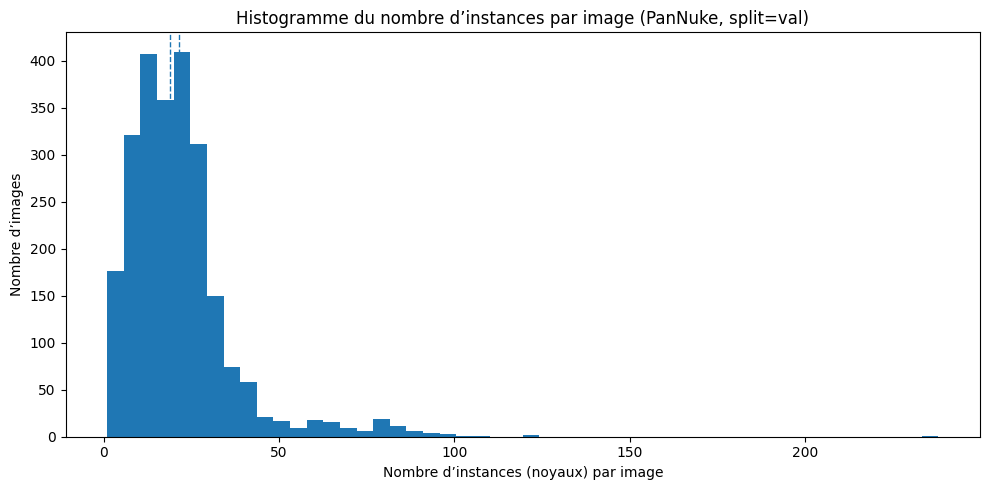

Saved: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\figure_3_2_hist_instances_per_image.png


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

CSV_PATH = Path("data/prepared/pannuke/pannuke_morphology_with_classes.csv")  # ajuste
SPLIT = "val"  # "train", "val", "test" ou None pour tout
BINS = 50
OUT = Path("figure_3_2_hist_instances_per_image.png")

df = pd.read_csv(CSV_PATH)

# Filtrer split si besoin
if SPLIT is not None:
    df = df[df["split"] == SPLIT].copy()

# nb instances par image = nb lignes (instances) par image
counts = df.groupby("image")["instance_id"].count().astype(int)

print("Nb images:", counts.shape[0])
print("Min:", counts.min(), "Max:", counts.max(), "Mean:", counts.mean(), "Median:", counts.median())

plt.figure(figsize=(10, 5))
plt.hist(counts.values, bins=BINS)
plt.title(f"Histogramme du nombre d’instances par image (PanNuke, split={SPLIT})")
plt.xlabel("Nombre d’instances (noyaux) par image")
plt.ylabel("Nombre d’images")

# repères utiles (très mémoire-friendly)
plt.axvline(counts.mean(), linestyle="--", linewidth=1)
plt.axvline(counts.median(), linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig(OUT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", OUT.resolve())


Nb instances: 51719
Min: 1.0 Max: 12805.0
Mean: 515.9824629246505 Median: 381.0
Q25: 199.0 Q75: 674.0 Q95: 1394.0999999999985


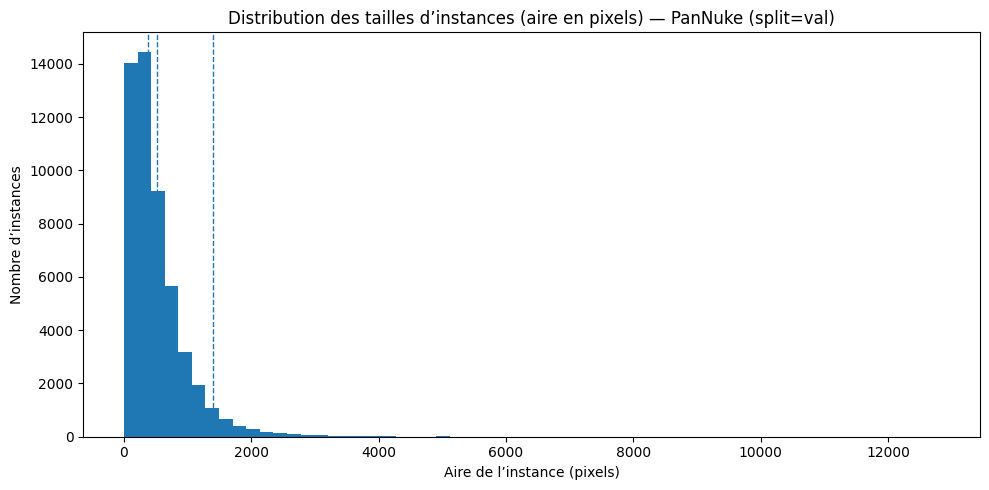

Saved: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\figure_3_3_instance_area_distribution.png


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

CSV_PATH = Path("data/prepared/pannuke/pannuke_morphology_with_classes.csv")  # ajuste
SPLIT = "val"   # "train" / "val" / "test" / None pour tout
BINS = 60
OUT = Path("figure_3_3_instance_area_distribution.png")

df = pd.read_csv(CSV_PATH)

if SPLIT is not None:
    df = df[df["split"] == SPLIT].copy()

areas = df["area"].dropna().astype(float).values

print("Nb instances:", len(areas))
print("Min:", areas.min(), "Max:", areas.max())
print("Mean:", areas.mean(), "Median:", np.median(areas))
print("Q25:", np.quantile(areas, 0.25), "Q75:", np.quantile(areas, 0.75), "Q95:", np.quantile(areas, 0.95))

plt.figure(figsize=(10, 5))
plt.hist(areas, bins=BINS)
plt.title(f"Distribution des tailles d’instances (aire en pixels) — PanNuke (split={SPLIT})")
plt.xlabel("Aire de l’instance (pixels)")
plt.ylabel("Nombre d’instances")

# repères utiles
plt.axvline(areas.mean(), linestyle="--", linewidth=1)
plt.axvline(np.median(areas), linestyle="--", linewidth=1)
plt.axvline(np.quantile(areas, 0.95), linestyle="--", linewidth=1)

plt.tight_layout()
plt.savefig(OUT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", OUT.resolve())


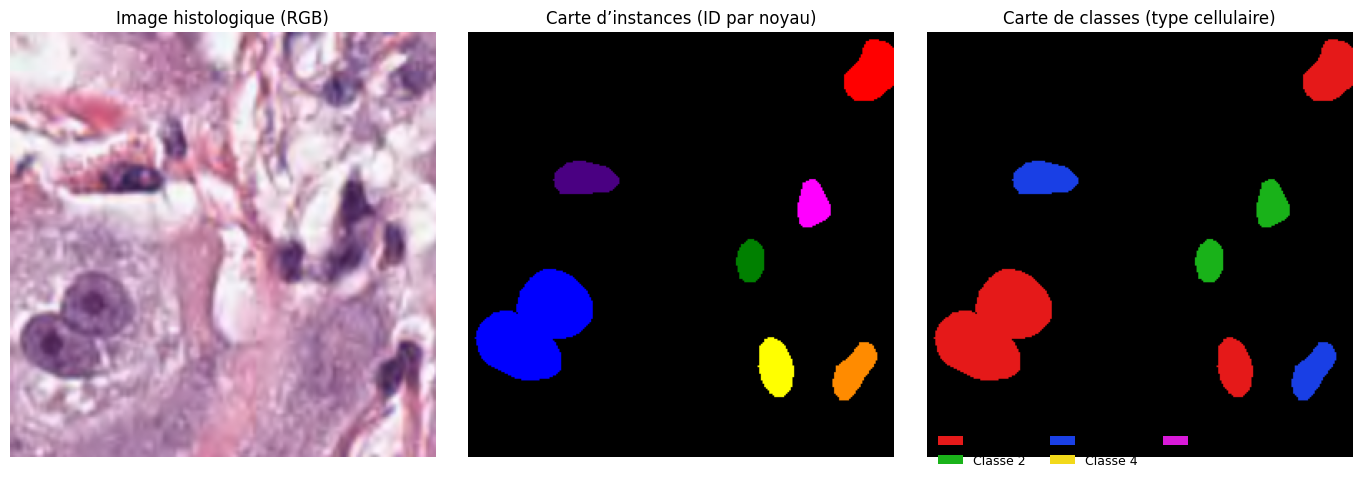

[OK] Sauvegardé: pannuke_triptych.png
[INFO] Exemple: split=train, index=0, fichier=img_000001.npy


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb
from pathlib import Path
from matplotlib.patches import Patch

def make_triptych(
    prepared_root="data/prepared/pannuke",
    split="train",
    index=0,
    out_path="pannuke_triptych.png",
    dpi=300,
):
    prepared_root = Path(prepared_root)

    img_files = sorted((prepared_root / split / "images").glob("img_*.npy"))
    if len(img_files) == 0:
        raise FileNotFoundError(f"Aucune image trouvée dans {prepared_root / split / 'images'}")

    img_path = img_files[index]
    mask_path = prepared_root / split / "masks" / img_path.name.replace("img_", "mask_")
    type_path = prepared_root / split / "types" / img_path.name.replace("img_", "type_")

    if not mask_path.exists():
        raise FileNotFoundError(f"Mask introuvable: {mask_path}")
    if not type_path.exists():
        raise FileNotFoundError(f"Type map introuvable: {type_path}")

    img = np.load(img_path)        # (H,W,3) float32 [0,1] chez toi
    inst = np.load(mask_path)      # (H,W) int/uint
    type_map = np.load(type_path)  # (H,W) uint8, 0=bg, 1..K

    # --- couleurs fixes par classe (0=bg = noir) ---
    class_colors = {
        0: (0.0, 0.0, 0.0),  # background
        1: (0.90, 0.10, 0.10),  # rouge
        2: (0.10, 0.70, 0.10),  # vert
        3: (0.10, 0.25, 0.90),  # bleu
        4: (0.95, 0.85, 0.10),  # jaune
        5: (0.85, 0.10, 0.85),  # magenta
    }

    # construire une image RGB pour la carte de classes
    type_rgb = np.zeros((*type_map.shape, 3), dtype=np.float32)
    for cid, col in class_colors.items():
        type_rgb[type_map == cid] = col

    # carte d'instances colorée (couleurs aléatoires, fond noir)
    inst_rgb = label2rgb(inst, bg_label=0, bg_color=(0, 0, 0))

    # ---- figure ----
    plt.figure(figsize=(14, 4.6))

    ax1 = plt.subplot(1, 3, 1)
    ax1.imshow(np.clip(img, 0, 1))
    ax1.set_title("Image histologique (RGB)")
    ax1.axis("off")

    ax2 = plt.subplot(1, 3, 2)
    ax2.imshow(inst_rgb)
    ax2.set_title("Carte d’instances (ID par noyau)")
    ax2.axis("off")

    ax3 = plt.subplot(1, 3, 3)
    ax3.imshow(type_rgb)
    ax3.set_title("Carte de classes (type cellulaire)")
    ax3.axis("off")

    # légende classes (si on veut des noms biologiques, adapte ici)
    class_names = {
        1: "Classe 1",
        2: "Classe 2",
        3: "Classe 3",
        4: "Classe 4",
        5: "Classe 5",
    }

    handles = []
    for cid in range(1, 6):
        handles.append(Patch(facecolor=class_colors[cid], edgecolor="none", label=class_names[cid]))

    ax3.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(0.0, -0.05),
        ncol=3,
        frameon=False,
        fontsize=9,
        title="Types",
        title_fontsize=10,
    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()

    print(f"[OK] Sauvegardé: {out_path}")
    print(f"[INFO] Exemple: split={split}, index={index}, fichier={img_path.name}")

if __name__ == "__main__":
    make_triptych(
        prepared_root="data/prepared/pannuke",
        split="train",
        index=0,
        out_path="pannuke_triptych.png",
        dpi=300,
    )



[train] n_images=2620
  mean=20.78 | median=18.00 | min=0 | max=234 | p95=44


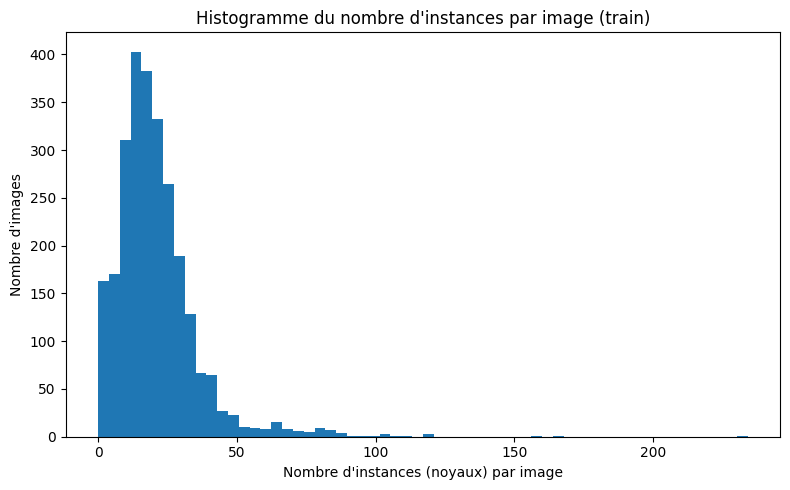


[val] n_images=2465
  mean=20.98 | median=19.00 | min=0 | max=238 | p95=48


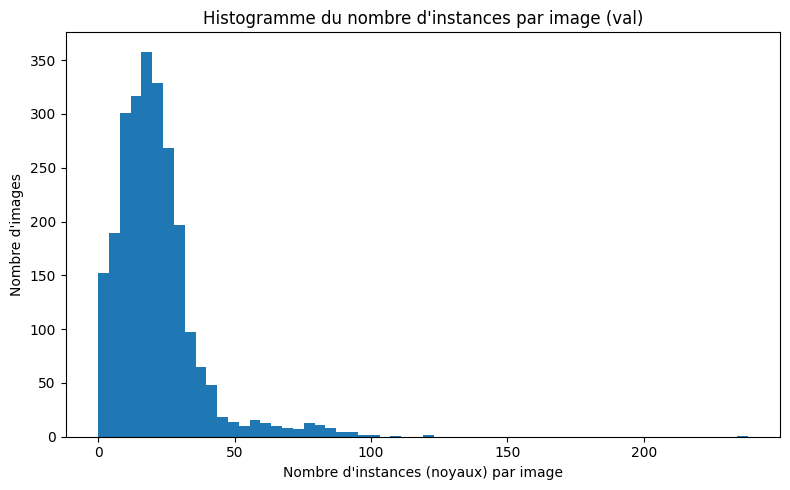


[test] n_images=2656
  mean=21.40 | median=18.00 | min=0 | max=186 | p95=48


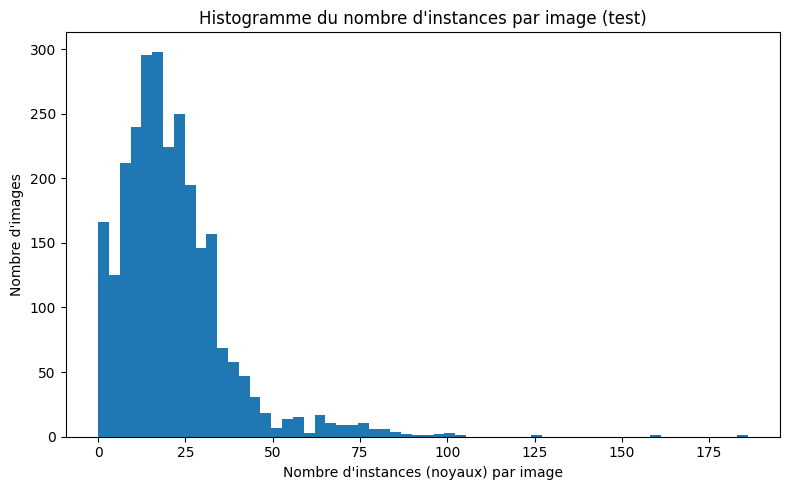

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def count_instances_in_mask(mask_path: Path) -> int:
    """mask: (H,W) avec IDs d'instances, 0 = fond"""
    m = np.load(mask_path)
    return int(m.max())  # IDs relabellisés 1..K donc max = nb d'instances

def plot_hist_instances_per_image(prepared_root: str, splits=("train", "val", "test"),
                                  bins=50, save_dir="figures", log_scale=False):
    prepared_root = Path(prepared_root)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    for split in splits:
        mask_dir = prepared_root / split / "masks"
        mask_files = sorted(mask_dir.glob("mask_*.npy"))
        if not mask_files:
            print(f"[WARN] Aucun mask trouvé pour split='{split}' dans {mask_dir}")
            continue

        counts = np.array([count_instances_in_mask(p) for p in mask_files], dtype=np.int32)

        # --- stats utiles pour ton texte ---
        print(f"\n[{split}] n_images={len(counts)}")
        print(f"  mean={counts.mean():.2f} | median={np.median(counts):.2f} | "
              f"min={counts.min()} | max={counts.max()} | p95={np.percentile(counts,95):.0f}")

        # --- figure ---
        plt.figure(figsize=(8, 5))
        plt.hist(counts, bins=bins)
        plt.title(f"Histogramme du nombre d'instances par image ({split})")
        plt.xlabel("Nombre d'instances (noyaux) par image")
        plt.ylabel("Nombre d'images")
        if log_scale:
            plt.yscale("log")

        plt.tight_layout()
        out_path = save_dir / f"pannuke_instances_per_image_{split}.png"
        plt.savefig(out_path, dpi=300)
        plt.show()

if __name__ == "__main__":
    plot_hist_instances_per_image(
        prepared_root="data/prepared/pannuke",
        splits=("train", "val", "test"),
        bins=60,          # ajuster si on veut plus/moins détaillé
        save_dir="figures",
        log_scale=False   # True si la distribution est très déséquilibrée
    )
